# Notebook 01 — Packet-Counter Reconstruction
**Thesis §4.2 | Input:** `data/0_cleaned_dataset_Obiri_2025_v2.csv` | **Output:** `data/1_reconstructed.csv`

---

## What this notebook does

Implements the packet-counter reconstruction pipeline described in §4.2 of the thesis.

| Step | Thesis section | Description |
|------|---------------|-------------|
| 0 | — | Imports, paths, plot style |
| 1 | §4.1 | Load and sort raw dataset |
| 2 | §4.2.1 | Reconstruction — derive $N_{\text{tx-loss}}$ and $N_{\text{fw-drop}}$ |
| 3 | §4.2.2 | Counter reset detection and removal |
| 4 | §4.2.1 | Counter divergence figure (Fig 05_01_a) — computed on clean data |
| 5 | §4.2.3 | Infrastructure outage detection (Fig 05_01_b) |
| 6 | §4.2.4 | Loss classification and packet decomposition (Fig 05_01_c) |
| 7 | §4.2.5 | PDR decomposition (Fig 05_01_d) |
| 8 | §4.2.5 | Per-device loss breakdown |
| 9 | — | Save reconstructed dataset |

**Variable naming convention:**

| Variable | Symbol | Meaning |
|----------|--------|---------|
| `tx_loss` | $N_{\text{tx-loss}}^{(i)}$ | Transmitted but lost — primary radio-layer loss metric |
| `fw_drop` | $N_{\text{fw-drop}}^{(i)}$ | Firmware drop before radio transmission |
| `t_radio` | $T_{\text{radio}}^{(i)}$ | Total radio transmission attempts |
| `t_sched` | $T_{\text{sched}}^{(i)}$ | Total scheduled transmissions |


## 0 · Imports & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
# Figure naming convention:  <thesis chapter>_<notebook>_<letter>_<topic>
#   e.g. 05_01_a_counter_divergence  ->  chapter 5, notebook 01, figure a
FIG_DIR = Path('../figures/1')
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_v2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.size': 12,
        'axes.titlesize': 13,
        'axes.labelsize': 13,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    }
)

C = {
    'blue': '#0077BB',
    'orange': '#EE7733',
    'green': '#009988',
    'red': '#CC3311',
    'purple': '#AA3377',
    'navy': '#004488',
    'grey': '#BBBBBB',
    'brown': '#882255',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: {FIG_DIR}/{name}.png')
    plt.show()


print(f'Ready. Data    → {DATA_DIR.resolve()}')
print(f'       Figures → {FIG_DIR.resolve()}')

Ready. Data    → D:\Thesis\lorawan_master_thesis\data
       Figures → D:\Thesis\lorawan_master_thesis\figures\1


## 1 · Load & Sort  *(§4.1)*

Timestamps parsed as UTC. Rows sorted per device by time before any processing.


In [2]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Period  : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'SF range: SF{int(df["SF"].min())}–SF{int(df["SF"].max())}')
print()
print(f'{"Device":<10} {"Rows":>12} {"% of total":>12}')
print('-' * 36)
for dev, g in df.groupby('device_id'):
    n = len(g)
    print(f'{dev:<10} {n:>12,} {n / len(df) * 100:>11.2f}%')
print('-' * 36)
print(f'{"Total":<10} {len(df):>12,} {"100.00%":>12}')

print('''
Which is expected, because in a year, we have 525,600 minutes. Exclude maintenance / outage occurences
''')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Period  : 2024-10-01 → 2025-09-30
SF range: SF7–SF12

Device             Rows   % of total
------------------------------------
ED0             440,166       16.71%
ED1             434,548       16.49%
ED2             440,920       16.73%
ED3             433,579       16.46%
ED4             435,416       16.52%
ED5             450,301       17.09%
------------------------------------
Total         2,634,930      100.00%

Which is expected, because in a year, we have 525,600 minutes. Exclude maintenance / outage occurences



## 2 · Reconstruction Algorithm  *(§4.2.1)*

**Counter definitions:**
- `f_count` = FCntUp — incremented by the end-device with each uplink transmission
- `p_count` = application counter — incremented by firmware for every scheduled packet

**Derived variables (thesis naming convention):**

| Column | Symbol | Meaning |
|--------|--------|---------|
| `tx_loss` | $N_{\text{tx-loss}}^{(i)}$ | $\max(0, \Delta f_i - 1)$ — transmitted but lost |
| `fw_drop` | $N_{\text{fw-drop}}^{(i)}$ | $\max(0, \Delta p_i - \Delta f_i)$ — firmware drop before radio |
| `t_radio` | $T_{\text{radio}}^{(i)}$ | $1 + N_{\text{tx-loss}}^{(i)}$ — total radio attempts |
| `t_sched` | $T_{\text{sched}}^{(i)}$ | $1 + N_{\text{tx-loss}}^{(i)} + N_{\text{fw-drop}}^{(i)}$ — total scheduled |


In [3]:
def reconstruct(grp):
    """
    Reconstruct tx_loss and fw_drop for one device.
    Rows must be sorted by time (guaranteed by Cell 1).
    Reset intervals (delta_f < 0) are flagged and zeroed — the true
    loss count during a device reboot is unrecoverable from the counter alone.
    """
    grp = grp.copy().reset_index(drop=True)
    delta_f = grp['f_count'].diff()
    delta_p = grp['p_count'].diff()

    is_reset = delta_f < 0  # device rebooted

    # N_tx-loss: transmitted but never arrived at network server
    tx_loss = (delta_f - 1).clip(lower=0)
    tx_loss[is_reset] = 0  # reset intervals uninformative
    tx_loss.iloc[0] = 0  # first row has no predecessor

    # N_fw-drop: scheduled by firmware but dropped before radio
    fw_drop = (delta_p - delta_f).clip(lower=0)
    fw_drop[is_reset] = 0
    fw_drop.iloc[0] = 0

    grp['tx_loss'] = tx_loss.astype(int)
    grp['fw_drop'] = fw_drop.astype(int)
    grp['t_radio'] = 1 + grp['tx_loss']  # T_radio: radio transmission attempts
    grp['t_sched'] = 1 + grp['tx_loss'] + grp['fw_drop']  # T_sched: all scheduled
    grp['is_reset'] = is_reset.fillna(False)
    return grp


device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction complete.')
print(f'  tx_loss total  (N_tx-loss) : {df["tx_loss"].sum():,}')
print(f'  fw_drop total  (N_fw-drop) : {df["fw_drop"].sum():,}')
print(f'  is_reset total             : {df["is_reset"].sum():,}')

Reconstruction complete.
  tx_loss total  (N_tx-loss) : 259,244
  fw_drop total  (N_fw-drop) : 251,370
  is_reset total             : 27


In [4]:
# Where do losses concentrate by SF?
loss_by_sf = df.groupby('SF')[['fw_drop', 'tx_loss']].sum()
loss_by_sf['fw_drop_pct'] = loss_by_sf['fw_drop'] / loss_by_sf['fw_drop'].sum() * 100
loss_by_sf['tx_loss_pct'] = loss_by_sf['tx_loss'] / loss_by_sf['tx_loss'].sum() * 100
print(loss_by_sf)

    fw_drop  tx_loss  fw_drop_pct  tx_loss_pct
SF                                            
7      3859    41906     1.535187    16.164694
8     14590    54231     5.804193    20.918903
9     50686    47166    20.163902    18.193671
10    28129    46072    11.190277    17.771675
11    79413    29604    31.592075    11.419358
12    74693    40265    29.714365    15.531700


## 3 · Counter Reset Detection  *(§4.2.2)*

A device reboot resets `f_count` to zero, producing a large negative $\Delta f_i$.
Without handling, such intervals inflate `tx_loss` by thousands.
Every interval where $\Delta f_i < 0$ is flagged as a reset, its `tx_loss` forced
to zero, and excluded from all loss computations.


In [5]:
print(f'{"Device":<10} {"Resets":>8}')
print('-' * 20)
for dev, g in df.groupby('device_id'):
    print(f'{dev:<10} {int(g["is_reset"].sum()):>8}')
print('-' * 20)
print(f'{"Total":<10} {int(df["is_reset"].sum()):>8}')
print()
print('Reset intervals: tx_loss set to 0, excluded from all loss computations.')

Device       Resets
--------------------
ED0               8
ED1               3
ED2               3
ED3               6
ED4               2
ED5               5
--------------------
Total            27

Reset intervals: tx_loss set to 0, excluded from all loss computations.


## 4 · Infrastructure Outage Detection  *(§4.2.3 — Fig 05_01_b)*

**Definition:** a period during which all six end devices simultaneously failed
to deliver data for longer than `MIN_DURATION` = 4 minutes.

**Algorithm:** for each device, find all silence gaps exceeding `MIN_DURATION`.
A confirmed outage is the intersection of overlapping silence intervals across
all six devices, subject to the same minimum duration.

In [6]:
# Ensure consistent chronological ordering
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# Each row represents the reconstructed interval:
# (previous received packet, current received packet]
df['interval_start'] = df.groupby('device_id', sort=False)['time'].shift(1)

# ──────────────────────────────────────────────────────────────────────────
# Gap distribution check (per device, per SF)
# ──────────────────────────────────────────────────────────────────────────
gaps_by_sf = []

for dev in sorted(df['device_id'].unique()):
    d = df.loc[df['device_id'] == dev].sort_values('time').copy()

    d['gap_min'] = d['time'].diff().dt.total_seconds() / 60

    d = d.dropna(subset=['gap_min'])
    gaps_by_sf.append(d[['SF', 'gap_min']])

all_gaps = pd.concat(gaps_by_sf, ignore_index=True)

print("Gap distribution by SF (minutes):")
print(
    all_gaps.groupby('SF')['gap_min']
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
    .to_string()
)

print(f"\nGaps > 10 min : {(all_gaps['gap_min'] > 10).sum():,}")
print(f"Gaps > 20 min : {(all_gaps['gap_min'] > 20).sum():,}")
print(f"Gaps > 30 min : {(all_gaps['gap_min'] > 30).sum():,}")
print(f"Gaps > 60 min : {(all_gaps['gap_min'] > 60).sum():,}")


Gap distribution by SF (minutes):
       count  mean    std   min   50%   75%   90%   95%   99%       max
SF                                                                     
7   537023.0  1.09  22.84  0.12  1.00  1.00  1.00  1.00  1.15  11535.51
8   534546.0  1.13  28.50  0.06  1.00  1.00  1.00  1.00  2.00  12004.94
9   518733.0  1.19  23.47  0.04  1.00  1.00  1.00  1.00  8.46  11530.97
10  500836.0  1.15  24.11  0.17  1.00  1.00  1.00  1.00  2.00  11983.16
11  269217.0  1.39  24.10  0.06  1.00  2.00  2.00  2.00  3.00  11984.33
12  274569.0  1.46  33.18  0.46  1.03  2.02  2.02  2.02  3.03  11985.50

Gaps > 10 min : 6,712
Gaps > 20 min : 488
Gaps > 30 min : 325
Gaps > 60 min : 207


In [7]:

# ──────────────────────────────────────────────────────────────────────────
# Infrastructure outage detection
#
# A confirmed outage is a silence interval lasting at least MIN_DURATION
# minutes (defined below) that overlaps across all six devices.
#
# IMPORTANT:
# tx_loss on row i represents losses occurring between interval_start and
# time. Therefore, outage filtering must flag reconstructed intervals that
# overlap the common silence window, not received-packet timestamps that
# fall inside the silence window.
# ──────────────────────────────────────────────────────────────────────────
DEVICES = sorted(df['device_id'].unique().tolist())
MIN_DURATION = 4  # minutes

# ── Step 1: identify silence gaps for each device ─────────────────────────
device_gaps = {}

for dev in DEVICES:
    d = (
        df.loc[df['device_id'] == dev, ['time']]
        .sort_values('time')
        .reset_index(drop=True)
        .copy()
    )

    d['previous_time'] = d['time'].shift(1)
    d['gap_min'] = (d['time'] - d['previous_time']).dt.total_seconds() / 60

    gaps = d.loc[d['gap_min'] >= MIN_DURATION, ['previous_time', 'time']].rename(
        columns={'previous_time': 'start', 'time': 'end'}
    )

    device_gaps[dev] = gaps.to_dict('records')


# ── Step 2: interval-intersection helper ──────────────────────────────────
def intersect_interval_lists(intervals_a, intervals_b, min_duration):
    """
    Return intersections lasting at least min_duration minutes between two
    chronologically sorted, non-overlapping interval lists.
    """
    intersections = []

    i = 0
    j = 0

    while i < len(intervals_a) and j < len(intervals_b):
        start = max(intervals_a[i]['start'], intervals_b[j]['start'])

        end = min(intervals_a[i]['end'], intervals_b[j]['end'])

        duration_min = (end - start).total_seconds() / 60

        if duration_min >= min_duration:
            intersections.append({'start': start, 'end': end})

        if intervals_a[i]['end'] < intervals_b[j]['end']:
            i += 1
        elif intervals_b[j]['end'] < intervals_a[i]['end']:
            j += 1
        else:
            i += 1
            j += 1

    return intersections


# ── Step 3: find silence intersections across all devices ────────────────
common_outages = device_gaps[DEVICES[0]]

for dev in DEVICES[1:]:
    common_outages = intersect_interval_lists(common_outages, device_gaps[dev], MIN_DURATION)

    if not common_outages:
        break

# ── Step 4: create outage table ──────────────────────────────────────────
if common_outages:
    outages_df = pd.DataFrame(common_outages).rename(
        columns={'start': 'start_time', 'end': 'end_time'}
    )

    outages_df = (
        outages_df.drop_duplicates(subset=['start_time', 'end_time'])
        .sort_values('start_time')
        .reset_index(drop=True)
    )

    outages_df['duration_minutes'] = (
        outages_df['end_time'] - outages_df['start_time']
    ).dt.total_seconds() / 60

    outages_df['duration_hours'] = outages_df['duration_minutes'] / 60

    outages_df['duration_days'] = outages_df['duration_minutes'] / 1440

else:
    outages_df = pd.DataFrame(
        columns=[
            'start_time',
            'end_time',
            'duration_minutes',
            'duration_hours',
            'duration_days',
        ]
    )

# ── Step 5: flag reconstructed intervals that overlap outages ────────────
df['is_outage'] = False

outage_coverage = []

for outage_id, outage in outages_df.iterrows():
    # Positive-duration overlap between:
    #
    # reconstructed interval: (interval_start, time]
    # confirmed outage:       [start_time, end_time]
    mask = (
        df['interval_start'].notna()
        & (df['interval_start'] < outage['end_time'])
        & (df['time'] > outage['start_time'])
    )

    df.loc[mask, 'is_outage'] = True

    outage_coverage.append(
        {
            'outage_id': outage_id + 1,
            'start_time': outage['start_time'],
            'end_time': outage['end_time'],
            'flagged_rows': int(mask.sum()),
            'covered_devices': int(df.loc[mask, 'device_id'].nunique()),
            'outage_tx_loss': int(df.loc[mask, 'tx_loss'].fillna(0).sum()),
        }
    )

outage_coverage_df = pd.DataFrame(outage_coverage)

# ── Step 6: separate outage losses from retained link losses ─────────────
df['outage_tx_loss'] = np.where(df['is_outage'], df['tx_loss'].fillna(0), 0).astype('int64')

df['link_tx_loss'] = np.where(df['is_outage'], 0, df['tx_loss'].fillna(0)).astype('int64')

# ── Step 7: summary and validation ───────────────────────────────────────
total_min = outages_df['duration_minutes'].sum()

print()
print(f'Confirmed outage events       : {len(outages_df):,}')
print(
    f'Total downtime                : {total_min:,.0f} min'
    f' / {total_min / 60:,.1f} hrs'
    f' / {total_min / 1440:,.1f} days'
)
print(f'Outage-overlapping rows       : {df["is_outage"].sum():,}')
print(f'Outage-attributed tx losses   : {df["outage_tx_loss"].sum():,}')
print(f'Remaining link tx losses      : {df["link_tx_loss"].sum():,}')

if not outage_coverage_df.empty:
    incomplete_outages = outage_coverage_df.loc[
        outage_coverage_df['covered_devices'] != len(DEVICES)
    ]

    print()
    print("Devices represented in each confirmed outage:")
    print(outage_coverage_df['covered_devices'].value_counts().sort_index().to_string())

    if incomplete_outages.empty:
        print(
            f"\nValidation passed: every confirmed outage overlaps "
            f"reconstructed intervals from all {len(DEVICES)} devices."
        )
    else:
        print("\nWARNING: Some confirmed outages did not map to all devices:")
        print(
            incomplete_outages[
                [
                    'outage_id',
                    'start_time',
                    'end_time',
                    'flagged_rows',
                    'covered_devices',
                    'outage_tx_loss',
                ]
            ].to_string(index=False)
        )

print()
print(f'{"Ev":^4} {"Date":^12} {"Start":^8} {"End":^8} {"Dur(h)":^10}')
print('-' * 48)

for i, row in outages_df.iterrows():
    print(
        f'{i + 1:^4} '
        f'{str(row["start_time"].date()):^12} '
        f'{str(row["start_time"].time())[:5]:^8} '
        f'{str(row["end_time"].time())[:5]:^8} '
        f'{row["duration_hours"]:^10.2f}'
    )


Confirmed outage events       : 84
Total downtime                : 37,686 min / 628.1 hrs / 26.2 days
Outage-overlapping rows       : 476
Outage-attributed tx losses   : 200,882
Remaining link tx losses      : 58,362

Devices represented in each confirmed outage:
covered_devices
6    84

Validation passed: every confirmed outage overlaps reconstructed intervals from all 6 devices.

 Ev      Date      Start     End      Dur(h)  
------------------------------------------------
 1    2024-10-09   14:15    14:19      0.07   
 2    2024-10-09   14:19    14:44      0.42   
 3    2024-10-10   10:19    11:45      1.43   
 4    2024-10-10   11:46    15:08      3.36   
 5    2024-10-11   13:09    13:24      0.26   
 6    2024-10-11   13:24    13:51      0.44   
 7    2024-10-11   14:25    15:35      1.18   
 8    2024-10-12   20:30    12:45     16.25   
 9    2024-10-14   14:31    14:44      0.23   
 10   2024-10-14   14:44    15:12      0.46   
 11   2024-10-14   15:13    15:32      0.30   
 

  Saved: ..\figures\1/05_01_b_outage_timing_diagram.png


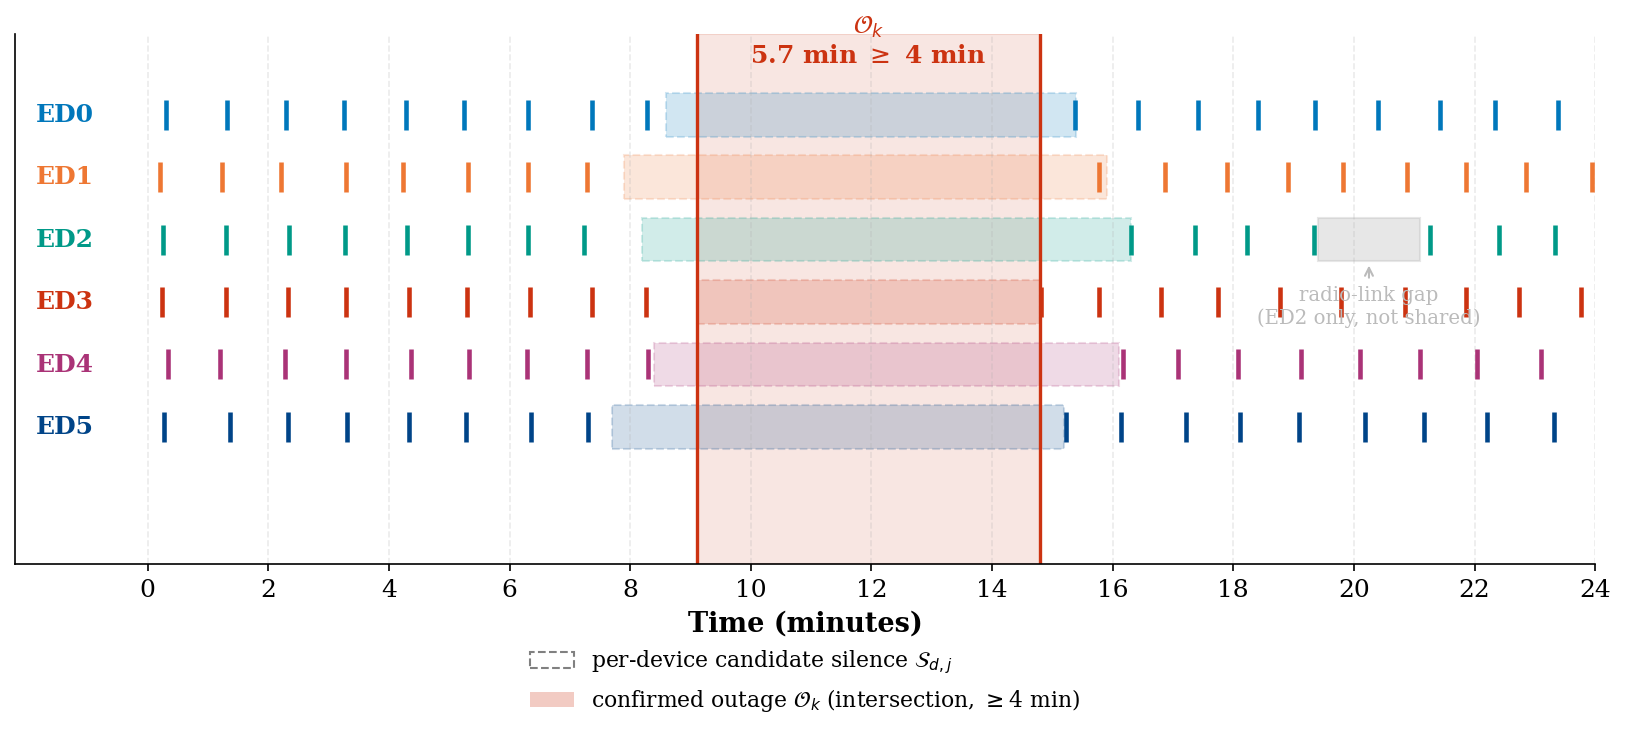

In [8]:
# All imports, plt.rcParams, C, and DEVICE_COLORS come from the
# setup cell above. mpatches is the only import this cell needs on its own.
import matplotlib.patches as mpatches

# Local device labels for the diagram only. Deliberately NOT named DEVICES,
# since that name is already bound to the real device_id list from the
# outage-detection cell above and is reused by later cells (loss
# classification, per-device PDR, rolling PDR). Overwriting it here would
# silently change what those cells iterate over.
plot_devices = [f'ED{d}' for d in range(6)]

rng = np.random.default_rng(7)

# ── one synthetic ~24-minute window per device ──────────────────────────────
# Each device transmits roughly once a minute. All six fall silent at
# slightly different moments and resume at slightly different moments,
# which is the entire reason S_d is per-device and O_k is their intersection.
window_end = 24.0
gap_start = {0: 8.6, 1: 7.9, 2: 8.2, 3: 9.1, 4: 8.4, 5: 7.7}   # last packet before silence
gap_end   = {0: 15.4, 1: 15.9, 2: 16.3, 3: 14.8, 4: 16.1, 5: 15.2}  # first packet after silence

packet_times = {}
for d in range(6):
    before = np.arange(0.3, gap_start[d], 1.0)
    after = np.arange(gap_end[d], window_end, 1.0)
    before = before + rng.normal(0, 0.05, size=len(before))
    after = after + rng.normal(0, 0.05, size=len(after))
    packet_times[d] = np.concatenate([before, after])

# a device-2-only gap that does NOT overlap the others: an ordinary radio-link
# gap, shown for contrast with the shared outage
solo_gap = (19.4, 21.1)
packet_times[2] = np.sort(np.concatenate([
    packet_times[2][packet_times[2] < solo_gap[0]],
    packet_times[2][packet_times[2] > solo_gap[1]],
]))

# ── the confirmed outage is the intersection of all six S_d ─────────────────
O_start = max(gap_start.values())
O_end = min(gap_end.values())
O_duration = O_end - O_start

# ── draw ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.2))
row_h = 0.7

for d in range(6):
    y = 5 - d
    color = DEVICE_COLORS[d]

    # each device's own candidate silence interval S_d, drawn as a light band
    ax.add_patch(mpatches.Rectangle(
        (gap_start[d], y - row_h/2), gap_end[d] - gap_start[d], row_h,
        facecolor=color, alpha=0.18, edgecolor=color, linewidth=1.0,
        linestyle='--', zorder=1,
    ))

    # received packets as ticks
    ax.plot(packet_times[d], [y] * len(packet_times[d]), '|', color=color,
            markersize=14, markeredgewidth=2.2, zorder=3)
    ax.text(-0.9, y, plot_devices[d], ha='right', va='center',
            fontsize=12, fontweight='bold', color=color)

# device-2 solo gap, contrasted as a radio-link-only silence (not shared)
y2 = 5 - 2
ax.add_patch(mpatches.Rectangle(
    (solo_gap[0], y2 - row_h/2), solo_gap[1] - solo_gap[0], row_h,
    facecolor=C['grey'], alpha=0.35, edgecolor=C['grey'], linewidth=1.0, zorder=1,
))
ax.annotate('radio-link gap\n(ED2 only, not shared)',
            xy=((solo_gap[0]+solo_gap[1])/2, y2 - row_h/2),
            xytext=((solo_gap[0]+solo_gap[1])/2, y2 - 1.35),
            ha='center', fontsize=9.5, color=C['grey'],
            arrowprops=dict(arrowstyle='->', color=C['grey'], lw=1.0))

# the confirmed outage: intersection across all six, shaded across full height
ax.axvspan(O_start, O_end, color=C['red'], alpha=0.12, zorder=0)
ax.axvline(O_start, color=C['red'], lw=1.6, zorder=2)
ax.axvline(O_end, color=C['red'], lw=1.6, zorder=2)
ax.annotate(
    r'$\mathcal{O}_k$' + f'\n{O_duration:.1f} min $\\geq$ 4 min',
    xy=((O_start + O_end) / 2, 5.75), ha='center', va='bottom',
    fontsize=12, fontweight='bold', color=C['red'],
)

ax.set_xlim(-2.2, window_end)
ax.set_ylim(-2.2, 6.3)
ax.set_yticks([])
ax.set_xlabel('Time (minutes)', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, int(window_end) + 1, 2))
ax.grid(axis='x', alpha=0.25, linestyle='--')

legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor='grey', linestyle='--',
                   label=r'per-device candidate silence $\mathcal{S}_{d,j}$'),
    mpatches.Patch(facecolor=C['red'], alpha=0.25,
                   label=r'confirmed outage $\mathcal{O}_k$ (intersection, $\geq$4 min)'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.32),
          frameon=False, fontsize=10.5)

fig.tight_layout()
save_fig(fig, '05_01_b_outage_timing_diagram')

## 5 · Counter Divergence: p_count vs f_count  *(§4.2.1 — Fig 05_01_a)*

Computed after both reset removal and outage detection, so the divergence
reflects only genuine firmware-level drops under normal operating conditions.
`p_count` consistently exceeds `f_count` across all devices, confirming
systematic firmware-level packet dropping. The divergence is consistent with
duty cycle enforcement (ETSI EN 300 220) and spreading factor rotation artefacts.


In [9]:
# Divergence computed on clean data — resets and outage intervals excluded
df_clean = df[~df['is_reset'] & ~df['is_outage']]

div = (
    df_clean.groupby('device_id')
    .agg(
        p_range=('p_count', lambda x: x.max() - x.min()),
        f_range=('f_count', lambda x: x.max() - x.min()),
    )
    .reset_index()
)
div['divergence'] = div['p_range'] - div['f_range']
div['pct'] = (div['divergence'] / div['p_range'] * 100).round(1)
mean_pct = div['pct'].mean()

print(f'{"Device":<8} {"p_range":>10} {"f_range":>10} {"divergence":>12} {"fw drop rate":>13}')
print('-' * 58)
for _, row in div.iterrows():
    print(
        f'{row["device_id"]:<8} {int(row["p_range"]):>10,} '
        f'{int(row["f_range"]):>10,} {int(row["divergence"]):>12,} {row["pct"]:>12.1f}%'
    )
print(f'\nMean firmware drop rate: {mean_pct:.1f}%')

Device      p_range    f_range   divergence  fw drop rate
----------------------------------------------------------
ED0         203,892    183,832       20,060          9.8%
ED1         363,579    322,404       41,175         11.3%
ED2         363,602    325,310       38,292         10.5%
ED3         251,675    223,786       27,889         11.1%
ED4         363,568    322,426       41,142         11.3%
ED5         363,709    331,372       32,337          8.9%

Mean firmware drop rate: 10.5%


  Saved: ..\figures\1/05_01_a_counter_divergence.png


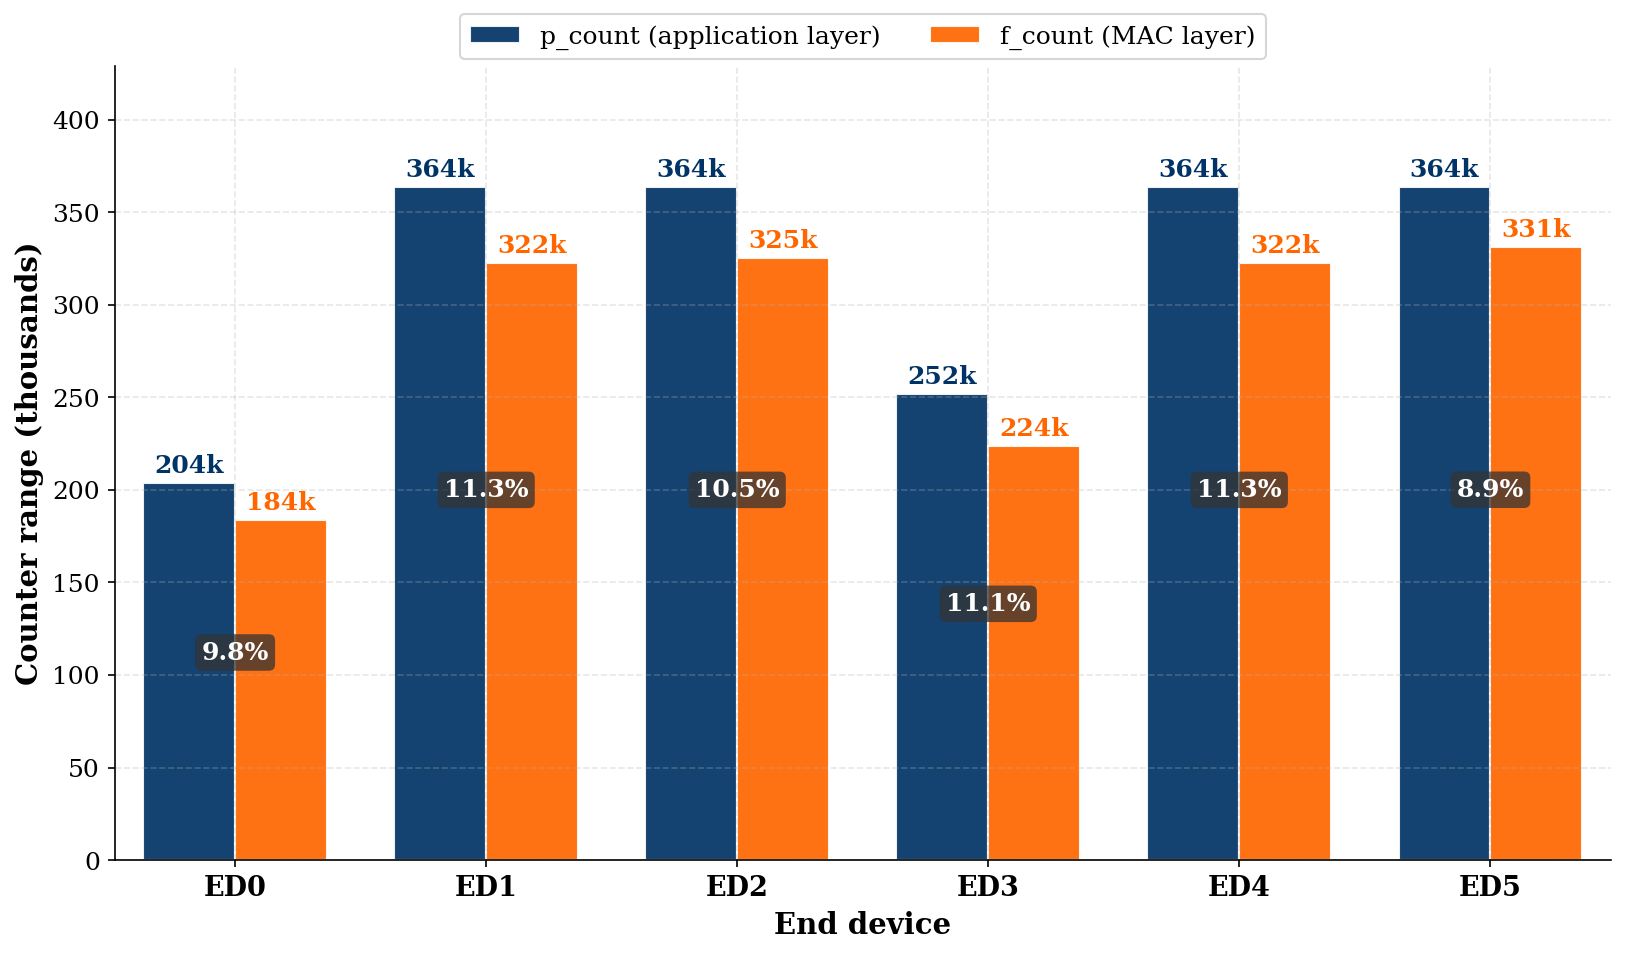

In [10]:
# Fig 05_01_a — p_count vs f_count divergence with fw drop rate annotated
DEVICES_D = div['device_id'].tolist()

# bring device groups closer together
x = np.arange(len(DEVICES_D)) * 0.82
w = 0.3

fig, ax = plt.subplots(figsize=(11, 6.5))

b1 = ax.bar(
    x - w / 2,
    div['p_range'] / 1000,
    w,
    color='#003366',
    alpha=0.92,
    edgecolor='white',
    label='p_count (application layer)',
)

b2 = ax.bar(
    x + w / 2,
    div['f_range'] / 1000,
    w,
    color='#FF6600',
    alpha=0.92,
    edgecolor='white',
    label='f_count (MAC layer)',
)

for bar_p, bar_f, row in zip(b1, b2, div.itertuples()):
    p_val = row.p_range / 1000
    f_val = row.f_range / 1000

    # p_count value on top
    ax.text(
        bar_p.get_x() + bar_p.get_width() / 2,
        p_val + 3,
        f'{p_val:.0f}k',
        ha='center',
        va='bottom',
        fontsize=12,
        color='#003366',
        fontweight='bold',
    )

    # f_count value on top
    ax.text(
        bar_f.get_x() + bar_f.get_width() / 2,
        f_val + 3,
        f'{f_val:.0f}k',
        ha='center',
        va='bottom',
        fontsize=12,
        color='#FF6600',
        fontweight='bold',
    )

    # fw drop rate between the two bars
    mid_x = (bar_p.get_x() + bar_p.get_width() + bar_f.get_x()) / 2
    ax.text(
        mid_x,
        max(p_val, f_val) * 0.55,
        f'{row.pct:.1f}%',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white',
        bbox=dict(
            boxstyle='round,pad=0.25', facecolor='#333333', alpha=0.75, edgecolor='none'
        ),
    )

ax.set_xticks(x)
ax.set_xticklabels(DEVICES_D, fontsize=13, fontweight='bold')
ax.set_ylabel('Counter range (thousands)', fontsize=14, fontweight='bold')
ax.set_xlabel('End device', fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=13)

ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=True)
ax.margins(y=0.18, x=0.02)

fig.tight_layout()
save_fig(fig, '05_01_a_counter_divergence')

## 6 · Transmission Decomposition  *(§4.2.4 — Fig 05_01_c)*

The 2,634,930 intervals decompose into four categories accounting for all 3,101,814
scheduled transmissions ($T_{\text{sched}}$):

| Category | Condition | Role |
|----------|-----------|------|
| Clean reception | `tx_loss = 0`, `is_outage = False` | Successfully received |
| Firmware drops | `fw_drop > 0` | Dropped before radio — excluded from analysis |
| Link losses | `tx_loss > 0`, `is_outage = False` | **Primary analysis target** |
| Infrastructure outages | `is_outage = True` | Excluded from event analysis |

$\mathcal{D}_{\text{link}}$ = all non-outage intervals.


In [11]:
# Zone classification
df['loss_zone'] = np.select(
    [df['is_outage'], df['tx_loss'] == 0], ['outage', 'no_loss'], default='radio_loss'
)

# ── Interval counts ───────────────────────────────────────────────────────────
print('Interval counts BEFORE reconstruction')
counts = df['loss_zone'].value_counts()
print(f'{"Zone":<15} {"Intervals":>12} {"Pct":>8}')
print('-' * 38)
for zone in ['no_loss', 'radio_loss', 'outage']:
    cnt = counts.get(zone, 0)
    print(f'{zone:<15} {cnt:>12,} {cnt / len(df) * 100:>7.2f}%')
print('-' * 38)
print(f'{"Total":<15} {len(df):>12,} {"100.00%":>8}')
print()

# ── Packet accounting (T_sched decomposition) ─────────────────────────────────
clean_pkts = df[df['loss_zone'] == 'no_loss'].shape[0]
fw_pkts = int(df['fw_drop'].sum())
link_pkts = int(df[df['loss_zone'] == 'radio_loss']['tx_loss'].sum())
outage_pkts = int(df[df['is_outage']]['tx_loss'].sum())
total_pkts = clean_pkts + fw_pkts + link_pkts + outage_pkts

print('Interval counts AFTER reconstruction')
print(f'{"Category":<25} {"Packets":>12} {"Pct":>8}')
print('-' * 47)
for label, val in [
    ('Successful transmissions', clean_pkts),
    ('Firmware drops (fw_drop)', fw_pkts),
    ('Link losses (tx_loss)', link_pkts),
    ('Infrastructure outages', outage_pkts),
]:
    print(f'{label:<25} {val:>12,} {val / total_pkts * 100:>7.2f}%')
print('-' * 47)
print(f'{"Total scheduled (T_sched)":<25} {total_pkts:>12,} {"100.00%":>8}')
print()
print(f'D_link (non-outage intervals) : {(~df["is_outage"]).sum():,}')

Interval counts BEFORE reconstruction
Zone               Intervals      Pct
--------------------------------------
no_loss            2,591,178   98.34%
radio_loss            43,276    1.64%
outage                   476    0.02%
--------------------------------------
Total              2,634,930  100.00%

Interval counts AFTER reconstruction
Category                       Packets      Pct
-----------------------------------------------
Successful transmissions     2,591,178   83.54%
Firmware drops (fw_drop)       251,370    8.10%
Link losses (tx_loss)           58,362    1.88%
Infrastructure outages         200,882    6.48%
-----------------------------------------------
Total scheduled (T_sched)    3,101,792  100.00%

D_link (non-outage intervals) : 2,634,454


  Saved: ..\figures\1/05_01_c_loss_classification.png


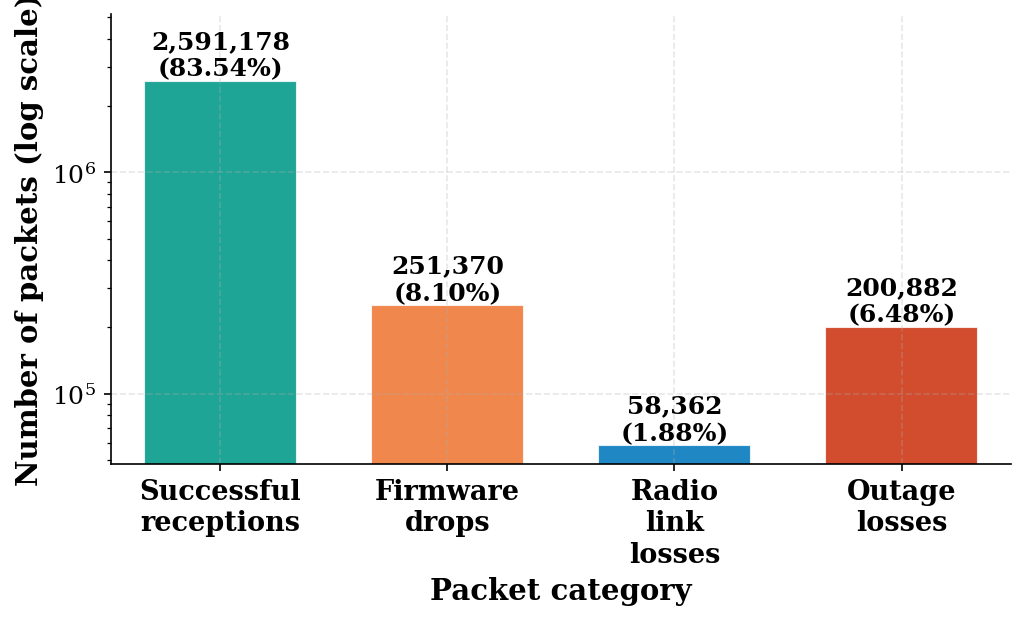

In [12]:
# Fig 05_01_c — Packet decomposition (§4.2.4)
pkt_labels = [
    'Successful\nreceptions',
    'Firmware\ndrops',
    'Radio\nlink\nlosses',
    'Outage\nlosses',
]
pkt_counts = [clean_pkts, fw_pkts, link_pkts, outage_pkts]
pkt_colors = [C['green'], C['orange'], C['blue'], C['red']]
pkt_pcts = [v / total_pkts * 100 for v in pkt_counts]

# bring categories closer together
x = np.arange(len(pkt_labels)) * 0.82
w = 0.55

fig, ax = plt.subplots(figsize=(7, 4.3))

bars = ax.bar(x, pkt_counts, w, color=pkt_colors, alpha=0.88, edgecolor='white')
ax.set_yscale('log')

for bar, cnt, pct in zip(bars, pkt_counts, pkt_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        cnt,
        f'{cnt:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
    )

# Set y upper limit to give labels breathing room without going above plot
ax.set_ylim(bottom=ax.get_ylim()[0], top=max(pkt_counts) * 2)

ax.set_xticks(x)
ax.set_xticklabels(pkt_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Number of packets (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Packet category', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.margins(x=0.04)

# ax.set_title(f'Packet Decomposition of the total scheduled transmissions ($\\mathbf{{T_{{\\mathrm{{sched}}}}}}$)', fontweight='bold')

fig.tight_layout()
save_fig(fig, '05_01_c_loss_classification')

## 7 · PDR Decomposition  *(§4.2.5 — Fig 05_01_d, Fig 05_01_e)*

Three PDR metrics, each isolating a different layer of the transmission pipeline:

| Metric | Losses included | Interpretation |
|--------|----------------|----------------|
| $\text{PDR}_{\text{system}}$ | $N_{\text{fw-drop}}$ + $N_{\text{tx-loss}}$ (all) | Application-layer reliability |
| $\text{PDR}_{\text{link+outage}}$ | $N_{\text{tx-loss}}$ (outages included) | Radio layer before outage filtering |
| $\text{PDR}_{\text{link}}$ | $N_{\text{tx-loss}}$ (outages excluded) | **Primary metric** |

$\text{PDR}_{\text{link}}$ is used in all event-conditioned analysis in Notebook 03.


In [13]:
total_rx = len(df)
total_fw_drop = int(df['fw_drop'].sum())
total_tx_loss = int(df['tx_loss'].sum())

df_link = df[~df['is_outage']]
total_link_loss = int(df_link['tx_loss'].sum())

pdr_system = total_rx / (total_rx + total_fw_drop + total_tx_loss) * 100
pdr_link_outage = total_rx / (total_rx + total_tx_loss) * 100
pdr_link = len(df_link) / (len(df_link) + total_link_loss) * 100

print(f'PDR_system      : {pdr_system:.2f}%   (fw_drop + tx_loss all)')
print(f'PDR_link+outage : {pdr_link_outage:.2f}%   (tx_loss, outages included)')
print(f'PDR_link        : {pdr_link:.2f}%   (tx_loss, outages excluded)')
print()
print(f'Firmware drops account for  : {pdr_link_outage - pdr_system:.2f} pp')
print(f'Outage removal accounts for : {pdr_link - pdr_link_outage:.2f} pp')
print()
print('Per-device PDR_link:')
for dev, g in df_link.groupby('device_id'):
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    dist = int(df[df['device_id'] == dev]['distance'].iloc[0])
    print(f'  {dev} ({dist}m): {rx / (rx + lost) * 100:.2f}%')

PDR_system      : 83.77%   (fw_drop + tx_loss all)
PDR_link+outage : 91.04%   (tx_loss, outages included)
PDR_link        : 97.83%   (tx_loss, outages excluded)

Firmware drops account for  : 7.28 pp
Outage removal accounts for : 6.79 pp

Per-device PDR_link:
  ED0 (10m): 97.88%
  ED1 (8m): 97.35%
  ED2 (23m): 98.12%
  ED3 (18m): 97.07%
  ED4 (37m): 97.66%
  ED5 (40m): 98.88%


## 8 · Per-Device Loss Breakdown  *(§4.2.5)*

Full decomposition per device. PDR_link values feed into thesis results.

`T_sched = Received + fw_drop + tx_loss(outage) + tx_loss(link)`


In [14]:
ROOM_LABELS = {
    'ED0': 'Hardware',
    'ED1': 'Lab',
    'ED2': 'Office',
    'ED3': 'Office',
    'ED4': 'Server Room',
    'ED5': 'Kitchen',
}

print(
    f'{"Dev":<6} {"Room":<12} {"Dist":^6} {"CW":^4} {"WW":^4} '
    f'{"Received":^10} {"fw_drop":^9} {"Outage":^9} {"Link Loss":^11} '
    f'{"PDR_sys":^9} {"PDR_l+o":^9} {"PDR_link":^10}'
)
print('-' * 118)

totals = {'rx': 0, 'fw': 0, 'outage': 0, 'link': 0}

for dev, g in df.groupby('device_id'):
    rx = len(g)
    fw = int(g['fw_drop'].sum())
    outage = int(g[g['is_outage']]['tx_loss'].sum())
    g_link = g[~g['is_outage']]
    link = int(g_link['tx_loss'].sum())
    radio_lost = outage + link

    for k, v in [('rx', rx), ('fw', fw), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_sys = rx / (rx + fw + radio_lost) * 100
    pdr_lo = rx / (rx + radio_lost) * 100
    pdr_lnk = len(g_link) / (len(g_link) + link) * 100

    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])
    room = ROOM_LABELS.get(dev, dev)

    print(
        f'{dev:<6} {room:<12} {dist:^6} {cw:^4} {ww:^4} '
        f'{rx:^10,} {fw:^9,} {outage:^9,} {link:^11,} '
        f'{pdr_sys:^9.2f} {pdr_lo:^9.2f} {pdr_lnk:^10.2f}'
    )

print('-' * 118)
t = totals
radio_lost = t['outage'] + t['link']
print(
    f'{"Total":<6} {"":<12} {"":^6} {"":^4} {"":^4} '
    f'{t["rx"]:^10,} {t["fw"]:^9,} {t["outage"]:^9,} {t["link"]:^11,} '
    f'{t["rx"] / (t["rx"] + t["fw"] + radio_lost) * 100:^9.2f} '
    f'{t["rx"] / (t["rx"] + radio_lost) * 100:^9.2f} '
    f'{t["rx"] / (t["rx"] + t["link"]) * 100:^10.2f}'
)

Dev    Room          Dist   CW   WW   Received   fw_drop   Outage    Link Loss   PDR_sys   PDR_l+o   PDR_link 
----------------------------------------------------------------------------------------------------------------------
ED0    Hardware       10    0    0    440,166    39,670    33,119      9,521      84.25     91.17     97.88   
ED1    Lab            8     1    0    434,548    44,862    33,530     11,848      82.80     90.54     97.35   
ED2    Office         23    0    2    440,920    42,083    33,395      8,427      84.01     91.34     98.12   
ED3    Office         18    1    2    433,579    43,688    33,414     13,063      82.78     90.32     97.07   
ED4    Server Room    37    0    5    435,416    45,534    33,404     10,420      82.97     90.86     97.66   
ED5    Kitchen        40    2    2    450,301    35,533    34,020      5,083      85.78     92.01     98.88   
--------------------------------------------------------------------------------------------------------

  Saved: ..\figures\1/05_01_d_pdr_decomposition.png


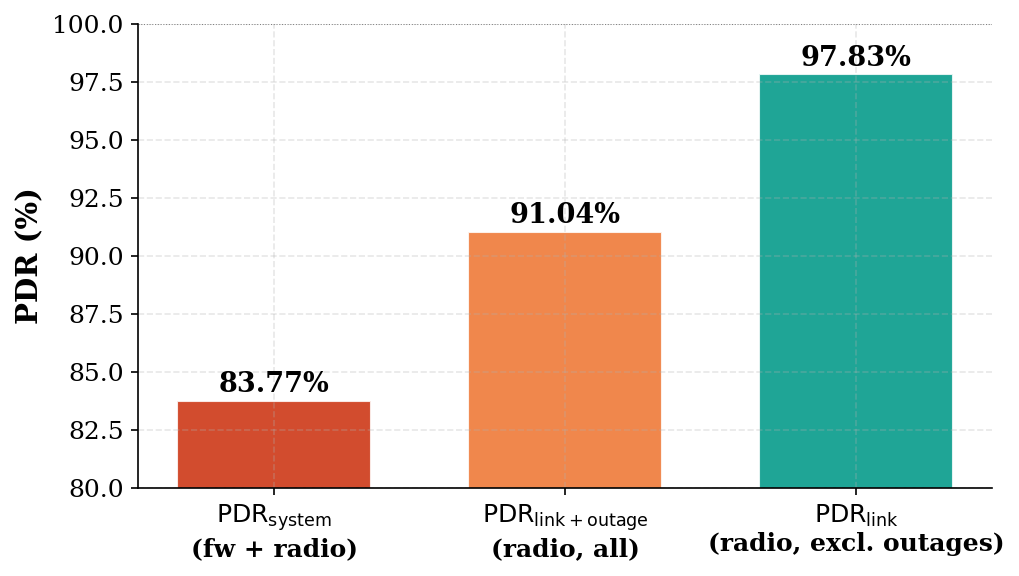

In [15]:
# Fig 05_01_d — PDR layer decomposition (§4.2.5)
fig, ax = plt.subplots(figsize=(7, 4))

categories = [
    r'$\mathrm{PDR_{system}}$' + '\n(fw + radio)',
    r'$\mathrm{PDR_{link+outage}}$' + '\n(radio, all)',
    r'$\mathrm{PDR_{link}}$' + '\n(radio, excl. outages)',
]
values_v = [pdr_system, pdr_link_outage, pdr_link]
colors_v = [C['red'], C['orange'], C['green']]

x = np.arange(len(categories)) * 0.75
w = 0.5
bars = ax.bar(x, values_v, w, color=colors_v, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        f'{v:.2f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
    )
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(80, 100)
ax.set_ylabel('PDR (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.axhline(y=100, color='grey', lw=0.5, ls=':')
ax.margins(x=0.05)
# ax.set_title('PDR Decomposition\nSystem → Link+Outage → Link')

fig.tight_layout()
save_fig(fig, '05_01_d_pdr_decomposition')

  Saved: ..\figures\1/05_01_e_pdr_per_device.png


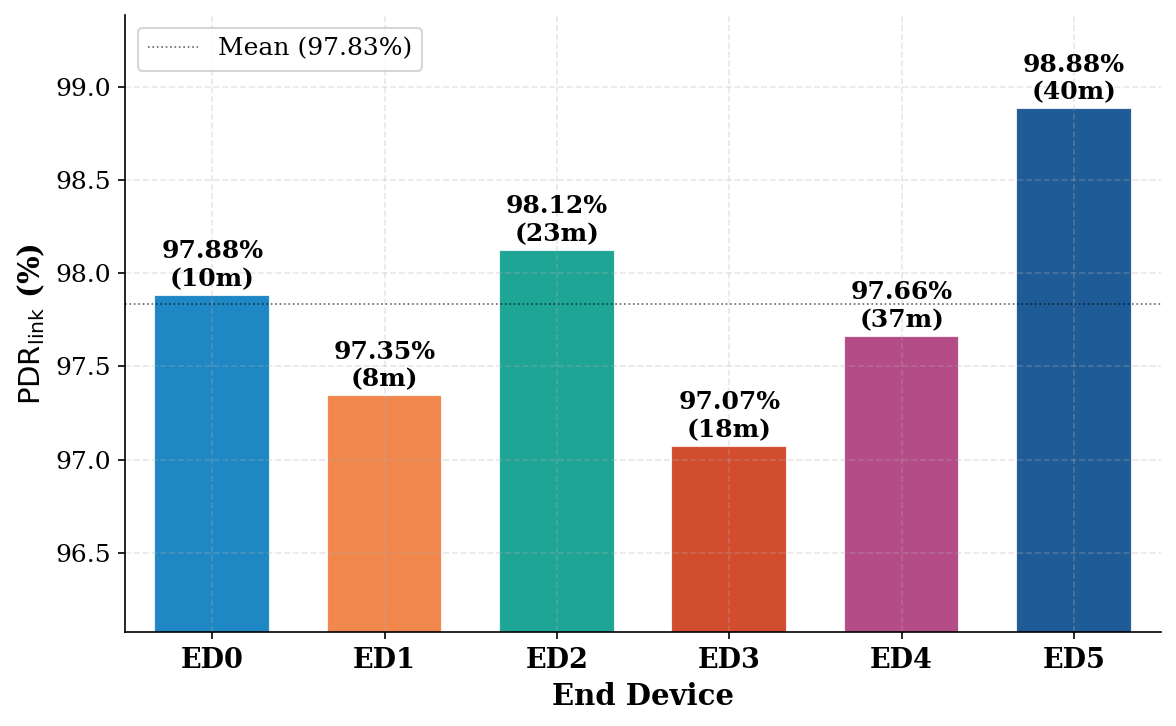

In [16]:
# ── Fig 05_01_e — PDR_link per device ───────────────────────────────────────────
DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g = df_link[df_link['device_id'] == dev]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    dev_pdrs.append(rx / (rx + lost) * 100)
    dev_dists.append(int(df[df['device_id'] == dev]['distance'].iloc[0]))

# bring device bars closer together
x = np.arange(len(DEVICES_P)) * 0.82
w = 0.55

fig, ax = plt.subplots(figsize=(8, 5))

bars2 = ax.bar(
    x, dev_pdrs, w, color=DEVICE_COLORS[: len(DEVICES_P)], alpha=0.88, edgecolor='white'
)
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02,
        f'{v:.2f}%\n({d}m)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
    )
ax.axhline(
    y=pdr_link, color='black', lw=0.8, ls=':', alpha=0.6, label=f'Mean ({pdr_link:.2f}%)'
)
ax.set_xticks(x)
ax.set_xticklabels(DEVICES_P, fontsize=13, fontweight='bold')
ax.set_ylabel(r'$\mathrm{PDR_{link}}$ (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('End Device', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(dev_pdrs) - 1, max(dev_pdrs) + 0.5)
ax.margins(x=0.03)
# ax.set_title(r'$\mathrm{PDR_{link}}$ per Device (distance annotated)')
ax.legend(fontsize=12)

fig.tight_layout()
save_fig(fig, '05_01_e_pdr_per_device')

## 9 · Baseline PDR & Rolling Time Series  *(§7.1)*

Per-device `PDR_link` is the baseline metric for all event-conditioned analysis.  
The near-uniform PDR across devices with vastly different link budgets is the  
first evidence for the collision-dominated loss hypothesis.

The rolling time series shows PDR stability over the full campaign and  
confirms that outage exclusion (`is_outage`) correctly isolates environmental losses.


In [17]:
print(
    f"{'Device':<8} {'Dist(m)':^8} {'CW':^4} {'WW':^4} {'Received':^10} "
    f"{'Link Lost':^11} {'PDR_link':^10}"
)
print('-' * 65)

pdrs = {}
for dev, g in df_link.groupby('device_id'):
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    pdrs[dev] = pdr
    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])
    print(f"{dev:<8} {dist:^8} {cw:^4} {ww:^4} {rx:^10,} {lost:^11,} {pdr:^10.2f}%")

print('-' * 65)
pdr_range = max(pdrs.values()) - min(pdrs.values())
print(f"PDR range across devices: {pdr_range:.2f} pp")
print(
    f"\nOnly {pdr_range:.2f} pp spread across devices with vastly different link budgets — "
    f"consistent with collision-dominated loss rather than signal quality degradation."
)

Device   Dist(m)   CW   WW   Received   Link Lost   PDR_link 
-----------------------------------------------------------------
ED0         10     0    0    440,086      9,521      97.88   %
ED1         8      1    0    434,470     11,848      97.35   %
ED2         23     0    2    440,840      8,427      98.12   %
ED3         18     1    2    433,499     13,063      97.07   %
ED4         37     0    5    435,336     10,420      97.66   %
ED5         40     2    2    450,223      5,083      98.88   %
-----------------------------------------------------------------
PDR range across devices: 1.81 pp

Only 1.81 pp spread across devices with vastly different link budgets — consistent with collision-dominated loss rather than signal quality degradation.


  Saved: ..\figures\1/05_01_f1_rolling_pdr_link_individual_7D.png


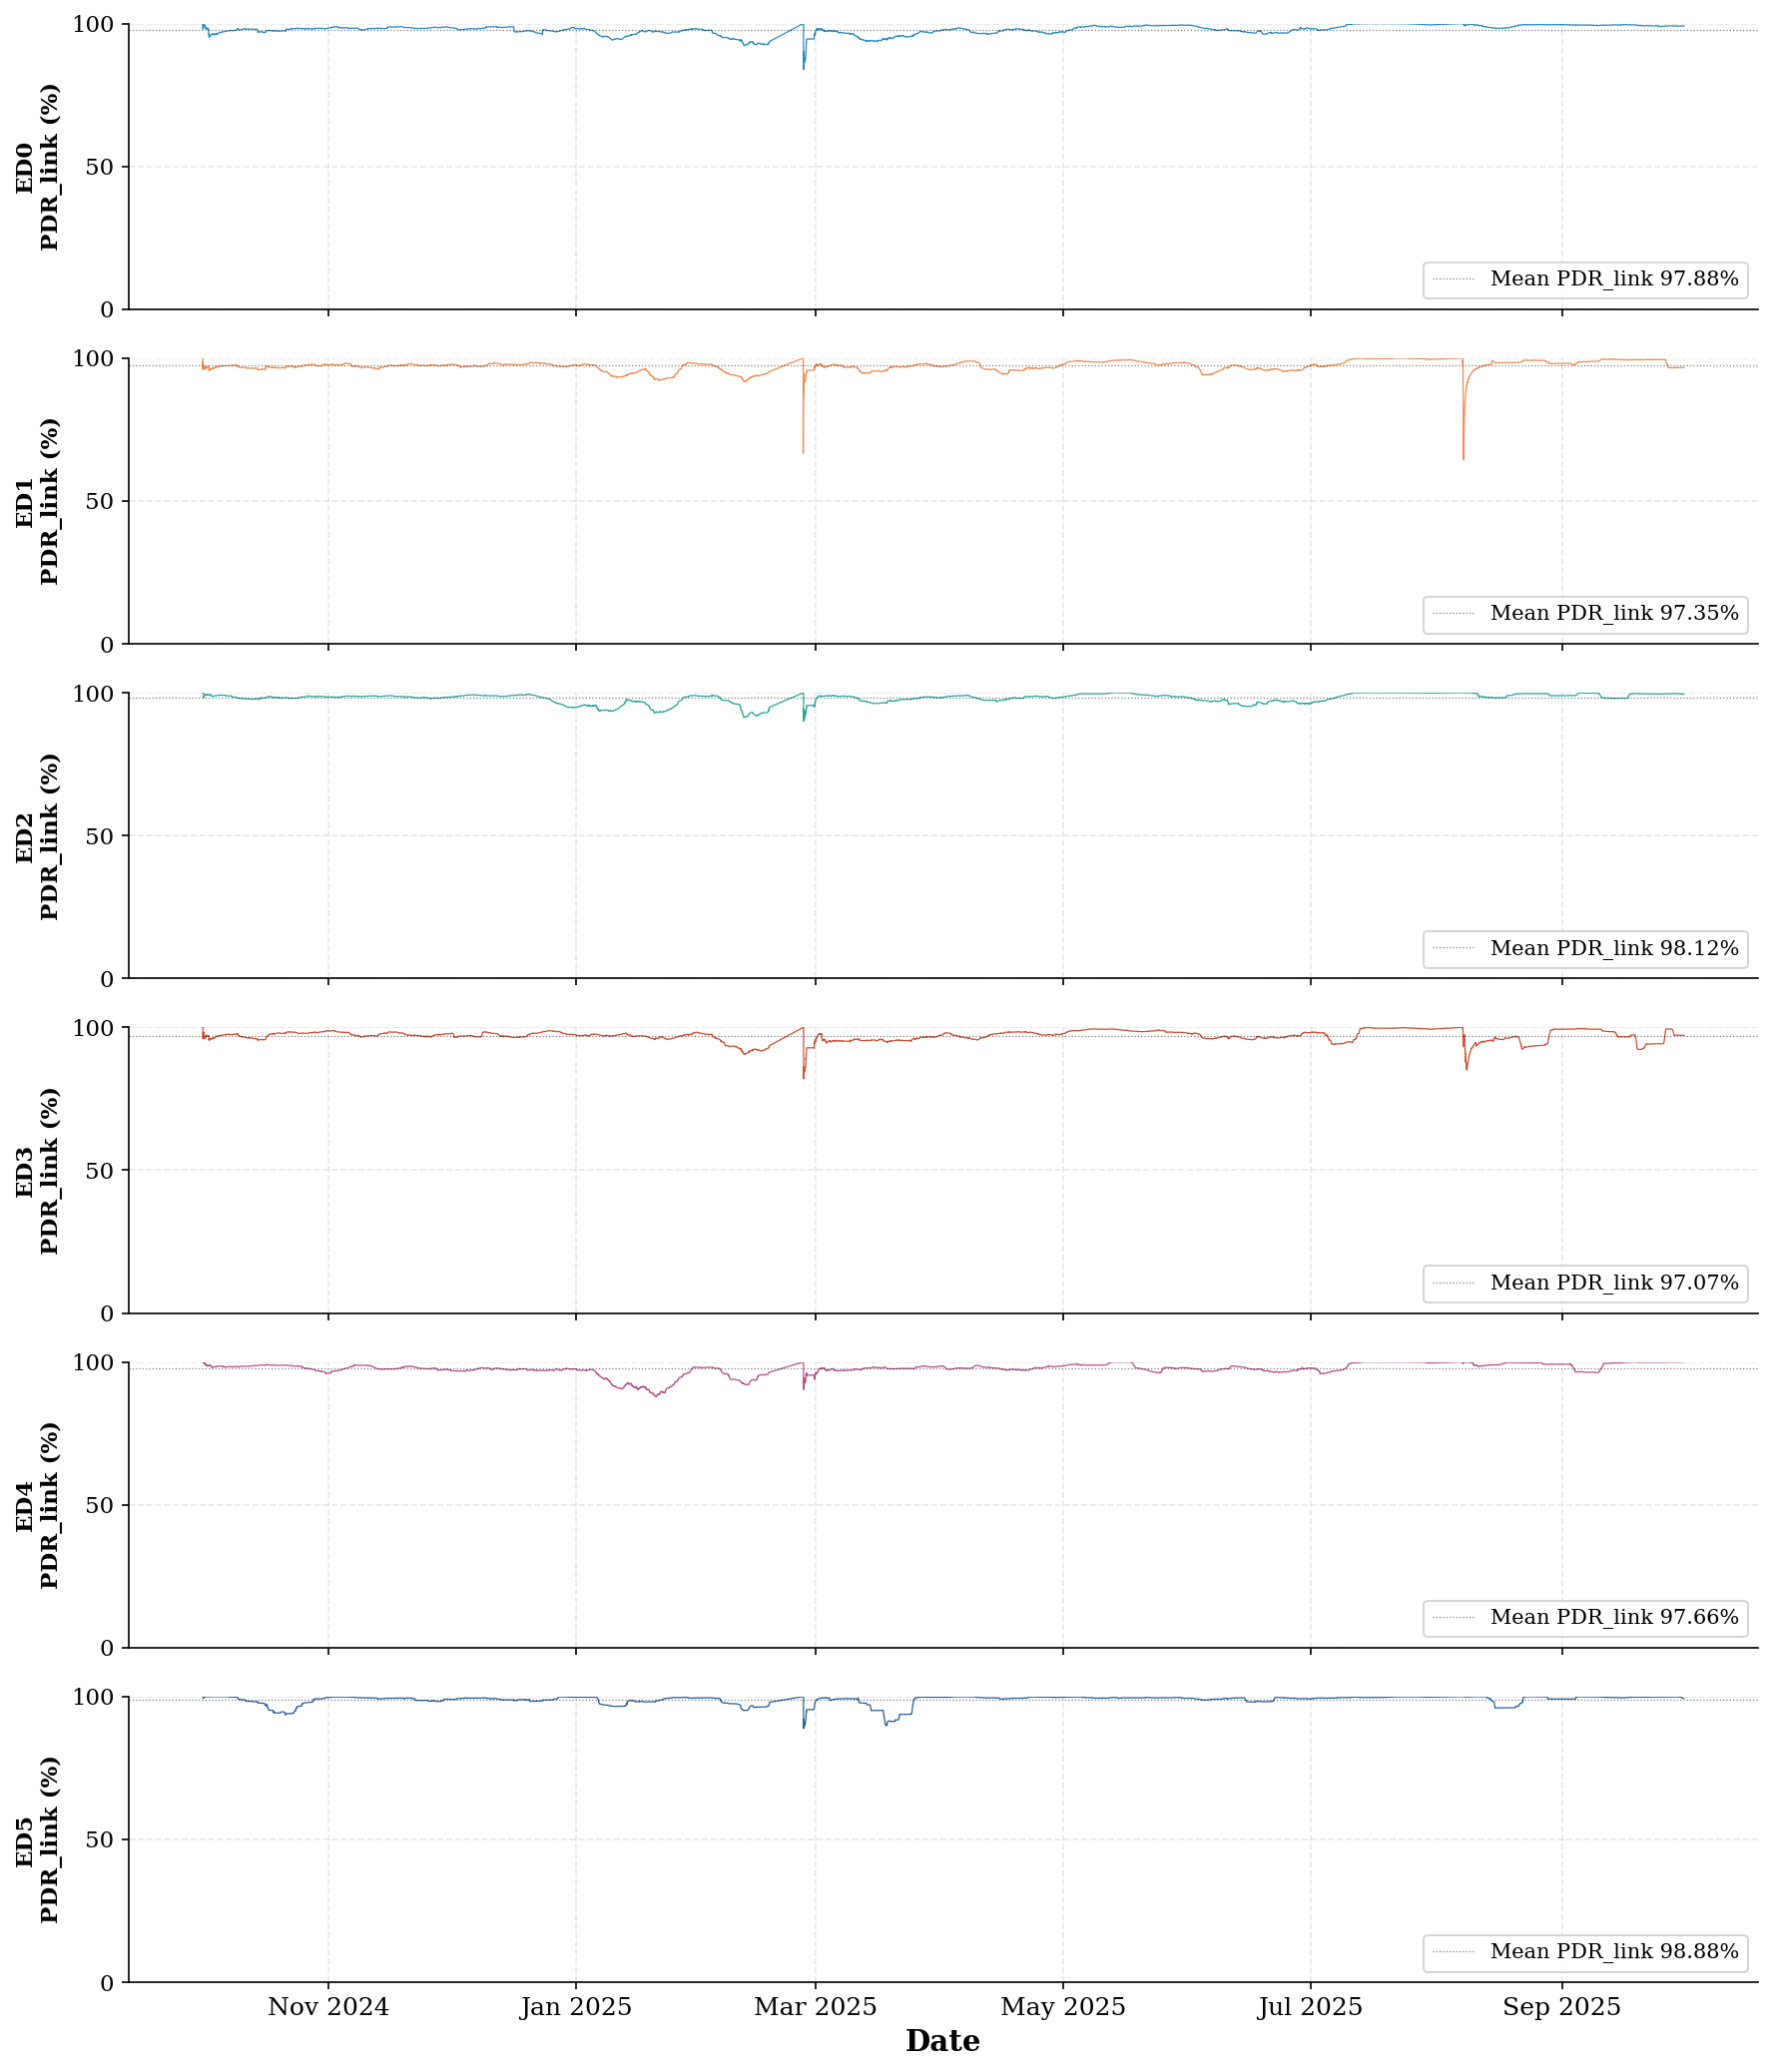

  Saved: ..\figures\1/05_01_f2_rolling_pdr_link_superimposed_7D.png


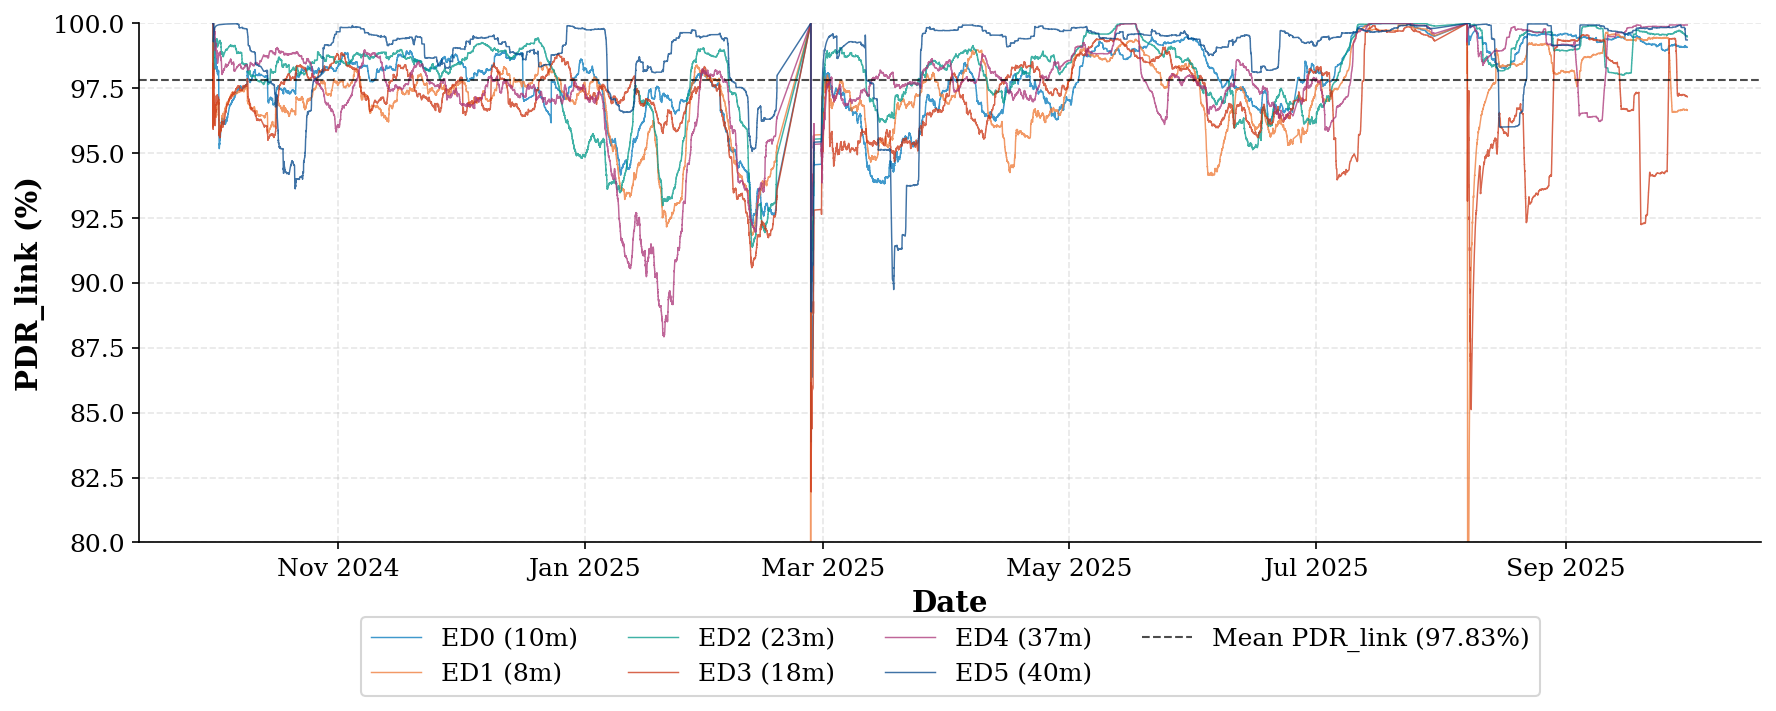

In [18]:
# Fig 05_01_f — Seven-day rolling PDR_link time series
#   e1 = one panel per device, e2 = all devices superimposed
ROLLING_WINDOW = '7D'  # options: '30min' | '2h' | '24h' | '7D'

DEVICES_A = sorted(df_link['device_id'].unique())

# ── Figure 1: individual subplots per device ─────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id'] == dev].copy().set_index('time').sort_index()

    g['rx1'] = 1

    rpdr = (
        g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum()
        / g['t_radio'].rolling(ROLLING_WINDOW, min_periods=1).sum()
        * 100
    ).clip(0, 100)

    axes[i].plot(rpdr.index, rpdr.values, linewidth=0.6, color=DEVICE_COLORS[i], alpha=0.85)

    pdr_link_dev = len(g) / (len(g) + int(g['tx_loss'].sum())) * 100

    axes[i].axhline(
        y=pdr_link_dev,
        color='black',
        lw=0.6,
        ls=':',
        alpha=0.5,
        label=f'Mean PDR_link {pdr_link_dev:.2f}%',
    )

    axes[i].set_ylabel(f'{dev}\nPDR_link (%)', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 100)
    axes[i].set_yticks([0, 50, 100])
    axes[i].tick_params(axis='y', labelsize=11)
    axes[i].legend(fontsize=10, loc='lower right')

axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
axes[-1].tick_params(axis='x', labelsize=12)

fig.tight_layout()
save_fig(fig, f'05_01_f1_rolling_pdr_link_individual_{ROLLING_WINDOW}')

# ── Figure 2: all devices superimposed on one axis ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id'] == dev].copy().set_index('time').sort_index()

    g['rx1'] = 1

    rpdr = (
        g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum()
        / g['t_radio'].rolling(ROLLING_WINDOW, min_periods=1).sum()
        * 100
    ).clip(0, 100)

    dist = int(g['distance'].iloc[0])

    ax.plot(
        rpdr.index,
        rpdr.values,
        linewidth=0.7,
        color=DEVICE_COLORS[i],
        alpha=0.75,
        label=f'{dev} ({dist}m)',
    )

# Campaign mean PDR_link across all devices
pdr_link_all = len(df_link) / (len(df_link) + int(df_link['tx_loss'].sum())) * 100

ax.axhline(
    y=pdr_link_all,
    color='black',
    lw=1.0,
    ls='--',
    alpha=0.7,
    label=f'Mean PDR_link ({pdr_link_all:.2f}%)',
)

ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(80, 100)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.32), fontsize=12)

fig.tight_layout()
fig.subplots_adjust(bottom=0.26)
save_fig(fig, f'05_01_f2_rolling_pdr_link_superimposed_{ROLLING_WINDOW}')

## 10 · Save  *(1_reconstructed.csv)*

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | `tx_loss`, `fw_drop`, `t_radio`, `t_sched`, `is_reset`, `is_outage`, `loss_zone` |


In [19]:
original_cols = [
    'device_id',
    'time',
    'co2',
    'humidity',
    'pm25',
    'pressure',
    'temperature',
    'rssi',
    'snr',
    'esp',
    'SF',
    'frequency',
    'toa',
    'distance',
    'c_walls',
    'w_walls',
    'exp_pl',
    'n_power',
    'f_count',
    'p_count',
]
derived_cols = [
    'tx_loss',  # N_tx-loss: transmitted but lost
    'fw_drop',  # N_fw-drop: firmware drop before radio
    't_radio',  # T_radio: total radio attempts
    't_sched',  # T_sched: total scheduled transmissions
    'is_reset',
    'is_outage',
    'loss_zone',
]

final_cols = [c for c in original_cols if c in df.columns] + [
    c for c in derived_cols if c in df.columns
]
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')

Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 27
